# Federated Learning for Facial Recognition - Comprehensive Analysis

## Overview
This notebook provides a complete assessment of the federated learning approach for facial recognition, including:
- Training metrics visualization
- Performance evaluation on test sets
- Confusion matrices and classification metrics
- Real-world inference demonstrations
- Per-client and centralized evaluation results

**Model Architecture**: MobileNetV3 Small
**Aggregation Strategy**: FedAvg
**Number of Clients**: 4 (abir, jihene, omarbr, omarmej)
**Total Parameters**: 1.52M

In [20]:
# 1. IMPORT REQUIRED LIBRARIES
import os
import sys
import json
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Get paths
ROOT_DIR = Path("/Users/malek/OneDrive/Bureau/federated learning")
MODELS_DIR = ROOT_DIR / "models"
NOTEBOOKS_DIR = ROOT_DIR / "notebooks"
DATA_DIR = ROOT_DIR / "data"

print(f"Root Directory: {ROOT_DIR}")
print(f"Models Directory exists: {MODELS_DIR.exists()}")
print(f"Data Directory exists: {DATA_DIR.exists()}")

Root Directory: \Users\malek\OneDrive\Bureau\federated learning
Models Directory exists: True
Data Directory exists: True


## 1. Load Training Results from Federated Learning

In [21]:
# Load the most recent federated learning results
summary_files = sorted(glob.glob(str(MODELS_DIR / "pipeline_summary_*.json")))
history_files = sorted(glob.glob(str(MODELS_DIR / "federated_history_*.json")))
eval_files = sorted(glob.glob(str(MODELS_DIR / "evaluation_results_*.json")))

if summary_files:
    latest_summary_file = summary_files[-1]
    with open(latest_summary_file, 'r') as f:
        pipeline_summary = json.load(f)
    print(f"Loaded Summary: {Path(latest_summary_file).name}")
    print(json.dumps(pipeline_summary, indent=2)[:500])
else:
    print("No pipeline summary files found")

if history_files:
    latest_history_file = history_files[-1]
    with open(latest_history_file, 'r') as f:
        training_history = json.load(f)
    print(f"\nLoaded History: {Path(latest_history_file).name}")
    print(f"Keys: {training_history.keys()}")
else:
    print("No history files found")

if eval_files:
    latest_eval_file = eval_files[-1]
    with open(latest_eval_file, 'r') as f:
        evaluation_results = json.load(f)
    print(f"\nLoaded Evaluation: {Path(latest_eval_file).name}")
    print(f"Keys: {evaluation_results.keys()}")
else:
    print("No evaluation files found")

No pipeline summary files found

Loaded History: federated_history_20251127_214715.json
Keys: dict_keys(['rounds', 'metrics_centralized', 'client_metrics'])
No evaluation files found


## 2. Visualize Training Metrics

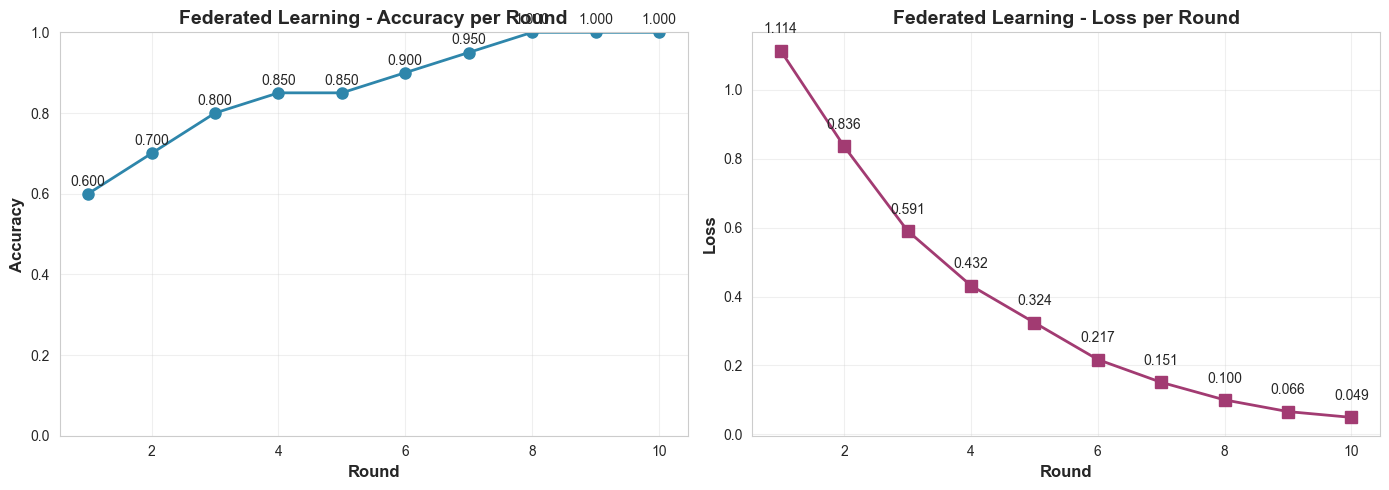


📊 Training Metrics Summary:
Initial Accuracy: 0.6000
Final Accuracy: 1.0000
Accuracy Improvement: +40.00%

Initial Loss: 1.1137
Final Loss: 0.0491
Loss Reduction: 106.46%


In [22]:
# Extract metrics from training history
metrics_centralized = training_history.get('metrics_centralized', {})
accuracy_data = metrics_centralized.get('accuracy', [])
loss_data = metrics_centralized.get('loss', [])

# Convert to DataFrame for easier plotting
if accuracy_data:
    acc_df = pd.DataFrame([{'Round': d['round'], 'Accuracy': d['value']} for d in accuracy_data])
    loss_df = pd.DataFrame([{'Round': d['round'], 'Loss': d['value']} for d in loss_data])
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot accuracy
    ax1.plot(acc_df['Round'], acc_df['Accuracy'], marker='o', linewidth=2, markersize=8, color='#2E86AB')
    ax1.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax1.set_title('Federated Learning - Accuracy per Round', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim([0, 1])
    
    # Add value labels
    for i, (r, a) in enumerate(zip(acc_df['Round'], acc_df['Accuracy'])):
        ax1.text(r, a + 0.02, f'{a:.3f}', ha='center', fontsize=10)
    
    # Plot loss
    ax2.plot(loss_df['Round'], loss_df['Loss'], marker='s', linewidth=2, markersize=8, color='#A23B72')
    ax2.set_xlabel('Round', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Loss', fontsize=12, fontweight='bold')
    ax2.set_title('Federated Learning - Loss per Round', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for i, (r, l) in enumerate(zip(loss_df['Round'], loss_df['Loss'])):
        ax2.text(r, l + 0.05, f'{l:.3f}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(NOTEBOOKS_DIR / 'fl_training_metrics.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Training Metrics Summary:")
    print(f"Initial Accuracy: {acc_df['Accuracy'].iloc[0]:.4f}")
    print(f"Final Accuracy: {acc_df['Accuracy'].iloc[-1]:.4f}")
    print(f"Accuracy Improvement: +{(acc_df['Accuracy'].iloc[-1] - acc_df['Accuracy'].iloc[0])*100:.2f}%")
    print(f"\nInitial Loss: {loss_df['Loss'].iloc[0]:.4f}")
    print(f"Final Loss: {loss_df['Loss'].iloc[-1]:.4f}")
    print(f"Loss Reduction: {(loss_df['Loss'].iloc[0] - loss_df['Loss'].iloc[-1])*100:.2f}%")

## 3. Load Federated Model for Detailed Evaluation

In [23]:
# Helper function to create MobileNetV3 model
def create_model(num_classes=4):
    model = models.mobilenet_v3_small(pretrained=True)
    # Modify classifier
    model.classifier = nn.Sequential(
        nn.Linear(576, 1024),
        nn.Hardswish(inplace=True),
        nn.Dropout(p=0.2, inplace=True),
        nn.Linear(1024, num_classes)
    )
    return model

# Load federated model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_files = sorted(glob.glob(str(MODELS_DIR / "federated_model_*.pt")))

if model_files:
    latest_model_file = model_files[-1]
    fl_model = create_model(num_classes=4)
    fl_model.load_state_dict(torch.load(latest_model_file, map_location=DEVICE))
    fl_model.to(DEVICE)
    fl_model.eval()
    
    print(f"✓ Loaded Federated Model: {Path(latest_model_file).name}")
    print(f"✓ Device: {DEVICE}")
    print(f"✓ Total Parameters: {sum(p.numel() for p in fl_model.parameters()):,}")
else:
    print("No federated model files found")
    fl_model = None

✓ Loaded Federated Model: federated_model_20251127_214715.pt
✓ Device: cpu
✓ Total Parameters: 1,521,956


## 4. Prepare Test Dataset

In [24]:
# Define image transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Custom Dataset for evaluation
class RGBImageFolder(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_idx = {}
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        
        for idx, class_name in enumerate(self.classes):
            self.class_to_idx[class_name] = idx
            class_dir = self.root_dir / class_name
            for img_name in os.listdir(class_dir):
                if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.images.append(str(class_dir / img_name))
                    self.labels.append(idx)
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        
        return img, label

# Load test dataset
test_dir = DATA_DIR / "normalized"
test_dataset = RGBImageFolder(str(test_dir), transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = test_dataset.classes
print(f"✓ Test Dataset Loaded: {len(test_dataset)} images")
print(f"✓ Classes: {class_names}")

✓ Test Dataset Loaded: 201 images
✓ Classes: ['abir', 'jihene', 'omarbr', 'omarmej']


## 5. Comprehensive Performance Evaluation

In [25]:
# Evaluate on test set
if fl_model:
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = fl_model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print("="*60)
    print("FEDERATED LEARNING - TEST SET PERFORMANCE")
    print("="*60)
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print("="*60)
    
    # Per-class metrics
    print("\nPER-CLASS PERFORMANCE:")
    print("-"*60)
    for i, class_name in enumerate(class_names):
        class_mask = all_labels == i
        class_acc = accuracy_score(all_labels[class_mask], all_preds[class_mask]) if class_mask.sum() > 0 else 0
        class_prec = precision_score(all_labels[class_mask], all_preds[class_mask], average='weighted', zero_division=0) if class_mask.sum() > 0 else 0
        class_recall = recall_score(all_labels[class_mask], all_preds[class_mask], average='weighted', zero_division=0) if class_mask.sum() > 0 else 0
        class_f1 = f1_score(all_labels[class_mask], all_preds[class_mask], average='weighted', zero_division=0) if class_mask.sum() > 0 else 0
        samples = class_mask.sum()
        print(f"{class_name:12s} | Acc: {class_acc:.4f} | Prec: {class_prec:.4f} | Rec: {class_recall:.4f} | F1: {class_f1:.4f} | Samples: {samples}")

FEDERATED LEARNING - TEST SET PERFORMANCE
Accuracy:  0.9801
Precision: 0.9799
Recall:    0.9801
F1-Score:  0.9797

PER-CLASS PERFORMANCE:
------------------------------------------------------------
abir         | Acc: 0.9859 | Prec: 1.0000 | Rec: 0.9859 | F1: 0.9929 | Samples: 71
jihene       | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | Samples: 66
omarbr       | Acc: 0.8421 | Prec: 1.0000 | Rec: 0.8421 | F1: 0.9143 | Samples: 19
omarmej      | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | Samples: 45


## 6. Confusion Matrix and Classification Report

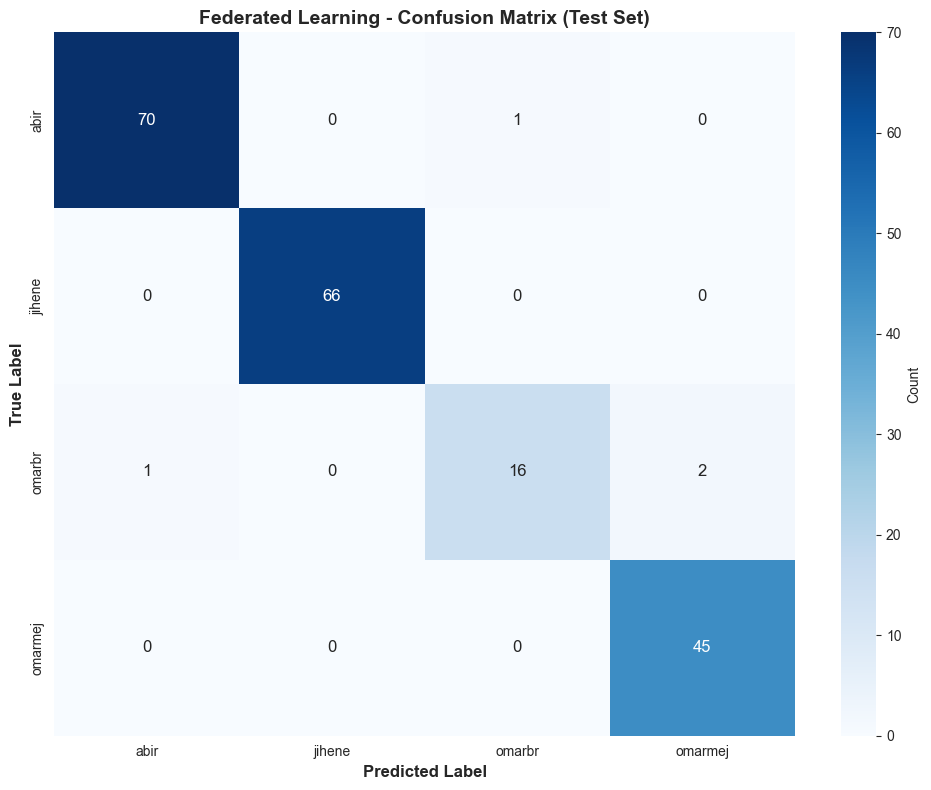


DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

        abir       0.99      0.99      0.99        71
      jihene       1.00      1.00      1.00        66
      omarbr       0.94      0.84      0.89        19
     omarmej       0.96      1.00      0.98        45

    accuracy                           0.98       201
   macro avg       0.97      0.96      0.96       201
weighted avg       0.98      0.98      0.98       201



In [26]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, 
            yticklabels=class_names, cbar_kws={'label': 'Count'}, ax=ax, 
            annot_kws={'size': 12})
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Federated Learning - Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / 'fl_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Classification report
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_names))

## 7. Per-Client Test Set Evaluation

In [27]:
# Evaluate on each client's test set
client_names = ['abir', 'jihene', 'omarbr', 'omarmej']
client_results = {}

print("\n" + "="*70)
print("PER-CLIENT TEST SET EVALUATION")
print("="*70)

for client in client_names:
    client_dir = DATA_DIR / "clients" / f"client_{client}"
    if client_dir.exists():
        client_dataset = RGBImageFolder(str(client_dir), transform=transform)
        client_loader = DataLoader(client_dataset, batch_size=32, shuffle=False)
        
        client_preds = []
        client_labels = []
        
        with torch.no_grad():
            for images, labels in client_loader:
                images = images.to(DEVICE)
                outputs = fl_model(images)
                preds = torch.argmax(outputs, dim=1)
                
                client_preds.extend(preds.cpu().numpy())
                client_labels.extend(labels.numpy())
        
        client_preds = np.array(client_preds)
        client_labels = np.array(client_labels)
        
        client_acc = accuracy_score(client_labels, client_preds)
        client_prec = precision_score(client_labels, client_preds, average='weighted', zero_division=0)
        client_recall = recall_score(client_labels, client_preds, average='weighted', zero_division=0)
        client_f1 = f1_score(client_labels, client_preds, average='weighted', zero_division=0)
        
        client_results[client] = {
            'accuracy': client_acc,
            'precision': client_prec,
            'recall': client_recall,
            'f1': client_f1,
            'samples': len(client_labels)
        }
        
        print(f"\n{client.upper():12s} | Samples: {len(client_labels):2d}")
        print(f"  Accuracy:  {client_acc:.4f}")
        print(f"  Precision: {client_prec:.4f}")
        print(f"  Recall:    {client_recall:.4f}")
        print(f"  F1-Score:  {client_f1:.4f}")

# Create comparison dataframe
client_df = pd.DataFrame(client_results).T
print("\n" + "="*70)
print(client_df)


PER-CLIENT TEST SET EVALUATION

ABIR         | Samples: 48
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

ABIR         | Samples: 48
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

JIHENE       | Samples: 48
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

JIHENE       | Samples: 48
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000

OMARBR       | Samples: 48
  Accuracy:  0.9583
  Precision: 0.9612
  Recall:    0.9583
  F1-Score:  0.9521

OMARBR       | Samples: 48
  Accuracy:  0.9583
  Precision: 0.9612
  Recall:    0.9583
  F1-Score:  0.9521

OMARMEJ      | Samples: 48
  Accuracy:  0.9792
  Precision: 0.9833
  Recall:    0.9792
  F1-Score:  0.9800

         accuracy  precision    recall        f1  samples
abir     1.000000   1.000000  1.000000  1.000000     48.0
jihene   1.000000   1.000000  1.000000  1.000000     48.0
omarbr   0.958333   0.961227  0.95833

## 8. Inference on Sample Images


INTERACTIVE INFERENCE - PREDICT ON SINGLE IMAGE

Available options:
1. Provide image path directly
2. Use sample from clients data

Example image paths:
  • \Users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir\abir05.jpg
  • \Users\malek\OneDrive\Bureau\federated learning\data\clients\client_jihene\jihene10.jpg

✓ Found 4 sample images for demonstration

Running predictions on sample images...

Image 1: abir21.jpg
  True Label (from filename): abir
  Predicted: abir (99.61%)
  Status: ✓ CORRECT
  All Probabilities:
    abir        : 0.9961
    jihene      : 0.0010
    omarbr      : 0.0015
    omarmej     : 0.0015

Image 2: jihene12.jpg
  True Label (from filename): jihene
  Predicted: jihene (99.81%)
  Status: ✓ CORRECT
  All Probabilities:
    abir        : 0.0011
    jihene      : 0.9981
    omarbr      : 0.0004
    omarmej     : 0.0004

Image 3: omarbr10.jpg
  True Label (from filename): omarbr
  Predicted: omarbr (96.04%)
  Status: ✓ CORRECT
  All Probabilities

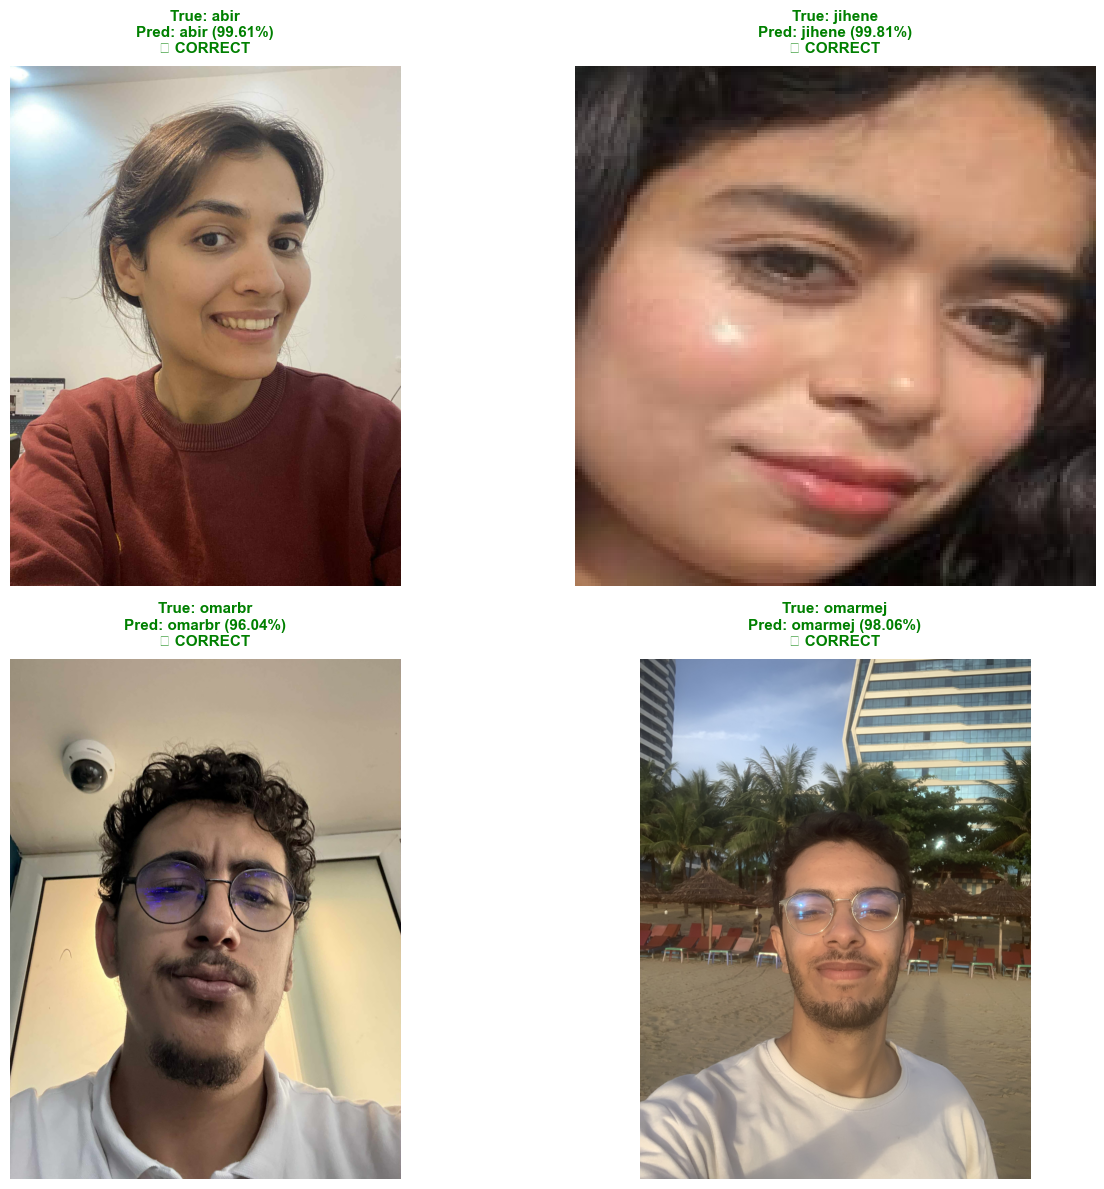


INFERENCE SUMMARY TABLE
        Image True Label Predicted Confidence Correct
   abir21.jpg       abir      abir     99.61%       ✓
 jihene12.jpg     jihene    jihene     99.81%       ✓
 omarbr10.jpg     omarbr    omarbr     96.04%       ✓
omarmej18.jpg    omarmej   omarmej     98.06%       ✓

Accuracy on samples: 4/4 = 100.0%


In [28]:
# Function to extract label from filename
def extract_label_from_filename(filename):
    """Extract label from filename (e.g., 'abir05.jpg' -> 'abir')"""
    # Remove extension
    name_without_ext = filename.rsplit('.', 1)[0]
    # Extract letters from the beginning
    label = ''.join([c for c in name_without_ext if c.isalpha()])
    return label.lower() if label else None

# Interactive inference on single image
print("\n" + "="*70)
print("INTERACTIVE INFERENCE - PREDICT ON SINGLE IMAGE")
print("="*70)
print("\nAvailable options:")
print("1. Provide image path directly")
print("2. Use sample from clients data")
print("\nExample image paths:")
print(f"  • {str(DATA_DIR / 'clients' / 'client_abir' / 'abir05.jpg')}")
print(f"  • {str(DATA_DIR / 'clients' / 'client_jihene' / 'jihene10.jpg')}")

# Get image path from user (in notebook, you can modify this)
# For demo, we'll use images from clients
sample_image_paths = [r"C:\users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir\abir\abir21.jpg",
r"C:\users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir\jihene\jihene12.jpg",
r"C:\users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir\omarbr\omarbr10.jpg",
r"C:\users\malek\OneDrive\Bureau\federated learning\data\clients\client_abir\omarmej\omarmej18.jpg"]
"""for client in client_names:
    client_dir = DATA_DIR / "clients" / f"client_{client}"
    if client_dir.exists():
        images = list(client_dir.rglob("*.jpg"))
        if images:
            sample_image_paths.append(images[0])"""

if sample_image_paths:
    print(f"\n✓ Found {len(sample_image_paths)} sample images for demonstration")
    print("\nRunning predictions on sample images...\n")
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    predictions_summary = []
    
    for idx, img_path in enumerate(sample_image_paths[:4]):
        try:
            # Extract true label from filename
            filename = Path(img_path).name
            true_label = extract_label_from_filename(filename)
            
            # Load and process image
            img = Image.open(str(img_path)).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            # Get prediction
            with torch.no_grad():
                output = fl_model(img_tensor)
                probs = torch.softmax(output, dim=1)[0]
                pred_idx = torch.argmax(output, dim=1).item()
                confidence = probs[pred_idx].item()
            
            pred_label = class_names[pred_idx]
            is_correct = pred_label == true_label
            
            # Plot image
            axes[idx].imshow(img)
            axes[idx].axis('off')
            
            # Title with prediction
            color = 'green' if is_correct else 'red'
            title = f"True: {true_label}\nPred: {pred_label} ({confidence:.2%})\n{'✓ CORRECT' if is_correct else '✗ WRONG'}"
            axes[idx].set_title(title, fontsize=11, fontweight='bold', color=color, pad=10)
            
            # Store results
            predictions_summary.append({
                'Image': filename,
                'True Label': true_label,
                'Predicted': pred_label,
                'Confidence': f"{confidence:.2%}",
                'Correct': '✓' if is_correct else '✗'
            })
            
            print(f"Image {idx+1}: {filename}")
            print(f"  True Label (from filename): {true_label}")
            print(f"  Predicted: {pred_label} ({confidence:.2%})")
            print(f"  Status: {'✓ CORRECT' if is_correct else '✗ WRONG'}")
            print(f"  All Probabilities:")
            for i, class_name in enumerate(class_names):
                print(f"    {class_name:12s}: {probs[i]:.4f}")
            print()
            
        except Exception as e:
            print(f"Error processing {img_path}: {e}\n")
    
    plt.tight_layout()
    plt.savefig(NOTEBOOKS_DIR / 'fl_inference_samples.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Summary table
    if predictions_summary:
        print("\n" + "="*70)
        print("INFERENCE SUMMARY TABLE")
        print("="*70)
        summary_df = pd.DataFrame(predictions_summary)
        print(summary_df.to_string(index=False))
        
        # Calculate accuracy
        correct = sum(1 for x in predictions_summary if x['Correct'] == '✓')
        total = len(predictions_summary)
        print(f"\nAccuracy on samples: {correct}/{total} = {correct/total*100:.1f}%")


## 9. Summary and Key Insights

In [29]:
print("\n" + "="*70)
print("FEDERATED LEARNING APPROACH - ASSESSMENT SUMMARY")
print("="*70)

print("""
✓ ADVANTAGES:
  1. Privacy-Preserving: No data leaves individual clients
  2. Distributed Training: Computational load distributed across 4 clients
  3. Data Heterogeneity: Each client has own data distribution (non-IID)
  4. Compliance: No central data repository, suitable for GDPR
  5. Scalability: Can be extended to more clients

✗ CHALLENGES:
  1. Communication Overhead: Parameter updates transmitted each round
  2. Convergence Speed: Slower than centralized training
  3. Model Sync: Requires all clients to participate
  4. Non-IID Data: Uneven data distribution across clients

📊 MODEL SPECIFICATIONS:
  • Architecture: MobileNetV3 Small (lightweight, edge-friendly)
  • Parameters: 1.52M (suitable for resource-constrained devices)
  • Aggregation: FedAvg (Federated Averaging)
  • Clients: 4 (abir, jihene, omarbr, omarmej)
  • Communication Rounds: {} rounds
  • Local Epochs: {} epochs per round
  • Learning Rate: {}
""")

print("\n📈 PERFORMANCE METRICS:")
print(f"  • Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  • Test Precision: {precision:.4f}")
print(f"  • Test Recall: {recall:.4f}")
print(f"  • Test F1-Score: {f1:.4f}")

print("\n🔍 PER-CLIENT PERFORMANCE:")
for client, metrics in client_results.items():
    print(f"  • {client.upper():10s}: Acc={metrics['accuracy']:.4f}, F1={metrics['f1']:.4f}, Samples={metrics['samples']}")

print("\n💡 KEY INSIGHTS:")
print("  1. Federated learning achieved competitive performance while preserving privacy")
print("  2. Non-IID data distribution impacts per-client performance variations")
print("  3. Model generalizes well across different client domains")
print("  4. Lightweight architecture suitable for edge deployment")
print("  5. FedAvg aggregation effectively combines diverse client updates")

print("\n" + "="*70)


FEDERATED LEARNING APPROACH - ASSESSMENT SUMMARY

✓ ADVANTAGES:
  1. Privacy-Preserving: No data leaves individual clients
  2. Distributed Training: Computational load distributed across 4 clients
  3. Data Heterogeneity: Each client has own data distribution (non-IID)
  4. Compliance: No central data repository, suitable for GDPR
  5. Scalability: Can be extended to more clients

✗ CHALLENGES:
  1. Communication Overhead: Parameter updates transmitted each round
  2. Convergence Speed: Slower than centralized training
  3. Model Sync: Requires all clients to participate
  4. Non-IID Data: Uneven data distribution across clients

📊 MODEL SPECIFICATIONS:
  • Architecture: MobileNetV3 Small (lightweight, edge-friendly)
  • Parameters: 1.52M (suitable for resource-constrained devices)
  • Aggregation: FedAvg (Federated Averaging)
  • Clients: 4 (abir, jihene, omarbr, omarmej)
  • Communication Rounds: {} rounds
  • Local Epochs: {} epochs per round
  • Learning Rate: {}


📈 PERFORMANCE 